In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import random
from matplotlib import pyplot as plt

In [3]:
# ============================================
# STEP 3: Set dataset path
# ============================================
# Change this path based on your Drive location
dataset_path = '/content/drive/MyDrive/image.orig'

# Check total images
all_images = sorted([os.path.join(dataset_path, f) for f in os.listdir(dataset_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
print(f"✅ Total images found: {len(all_images)}")

✅ Total images found: 1000


In [4]:
# ============================================
# STEP 4: Group images into 10 classes (based on index)
# ============================================
classes = [f'class_{i}' for i in range(10)]
data = {}

for i, cls in enumerate(classes):
    start_idx = i * 100
    end_idx = (i + 1) * 100
    imgs = all_images[start_idx:end_idx]
    train, test = train_test_split(imgs, test_size=0.2, random_state=42)
    data[cls] = {'train': train, 'test': test}

print("✅ Dataset split complete (80% train, 20% test per class)")

✅ Dataset split complete (80% train, 20% test per class)


In [5]:
# ============================================
# STEP 5: RLE Encoding functions
# ============================================
def rle_encode(img):
    pixels = img.flatten()
    runs = []
    prev_pixel = pixels[0]
    count = 1
    for pixel in pixels[1:]:
        if pixel == prev_pixel:
            count += 1
        else:
            runs.append((prev_pixel, count))
            prev_pixel = pixel
            count = 1
    runs.append((prev_pixel, count))
    return runs

def rle_size(runs):
    return len(runs) * 2  # (value, count)

In [6]:
# ============================================
# STEP 6: Compute average RLE coding efficiency per class
# ============================================
coding_efficiencies = {}

for cls in tqdm(classes, desc="Computing RLE efficiency"):
    cls_eff = []
    for img_path in data[cls]['train']:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        original_size = img.size
        rle = rle_encode(img)
        encoded_size = rle_size(rle)
        efficiency = original_size / encoded_size
        cls_eff.append(efficiency)
    coding_efficiencies[cls] = np.mean(cls_eff)

print("\n📊 Average RLE Coding Efficiency per Class:")
for cls, eff in coding_efficiencies.items():
    print(f"{cls}: {eff:.3f}")

Computing RLE efficiency: 100%|██████████| 10/10 [00:40<00:00,  4.10s/it]


📊 Average RLE Coding Efficiency per Class:
class_0: 0.655
class_1: 0.690
class_2: 0.609
class_3: 1.050
class_4: 0.914
class_5: 0.672
class_6: 0.698
class_7: 0.580
class_8: 0.637
class_9: 0.603


In [7]:
# ============================================
# STEP 7: R3 Coding with Gaussian Noise + Voting
# ============================================
def add_gaussian_noise(img, std=20):
    noise = np.random.normal(0, std, img.shape)
    noisy = img + noise
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)
    return noisy

def r3_transmit(img, std=20):
    copies = [add_gaussian_noise(img, std) for _ in range(3)]
    stacked = np.stack(copies, axis=-1)
    voted = np.median(stacked, axis=-1).astype(np.uint8)
    return voted

def compute_mse(img1, img2):
    return np.mean((img1.astype(np.float32) - img2.astype(np.float32)) ** 2)

In [8]:

# ============================================
# STEP 8: Compute MSE per class (test set)
# ============================================
mse_per_class = {}

for cls in tqdm(classes, desc="Transmitting images (R3 + noise)"):
    cls_mse = []
    for img_path in data[cls]['test']:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        received = r3_transmit(img, std=20)
        mse = compute_mse(img, received)
        cls_mse.append(mse)
    mse_per_class[cls] = np.mean(cls_mse)

print("\n📉 Average MSE per Class after R3 transmission:")
for cls, mse in mse_per_class.items():
    print(f"{cls}: {mse:.3f}")

Transmitting images (R3 + noise): 100%|██████████| 10/10 [00:05<00:00,  1.91it/s]


📉 Average MSE per Class after R3 transmission:
class_0: 175.673
class_1: 170.316
class_2: 169.447
class_3: 171.209
class_4: 175.357
class_5: 168.747
class_6: 164.137
class_7: 174.333
class_8: 176.824
class_9: 169.995


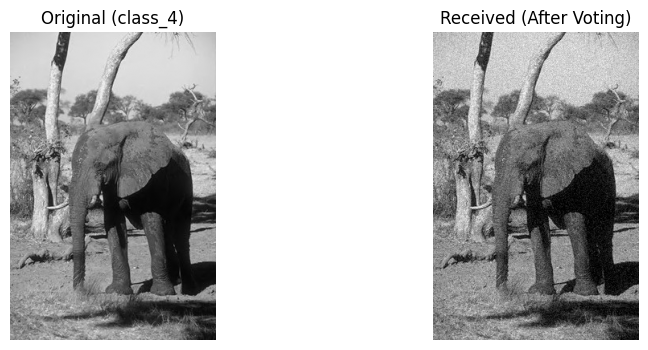

In [9]:
# ============================================
# STEP 9: Visualization Example
# ============================================
sample_cls = random.choice(classes)
sample_img_path = random.choice(data[sample_cls]['test'])
sample_img = cv2.imread(sample_img_path, cv2.IMREAD_GRAYSCALE)
received_img = r3_transmit(sample_img, std=20)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title(f"Original ({sample_cls})")
plt.imshow(sample_img, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Received (After Voting)")
plt.imshow(received_img, cmap='gray')
plt.axis('off')
plt.show()

RLE is efficient for images with uniform patterns but not for highly detailed ones, and R3 coding with majority voting effectively restores images under noise, with some variation in reconstruction quality across classes.
